<a href="https://colab.research.google.com/github/vfontama/mynewrepo/blob/main/try_it_22_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Try-It Activity 22.2: Sequential Data Models with Keras [2:00:00]

This try-it focuses on using `keras` to build models on sequential data.  This could either be sequential numeric data *or* you can consider text as sequential data.  `keras` contains both preprocessing tools similar to that of the `ImageDataGenerator` for time series and text data.  There are also various layer architectures to choose from including the `LSTM`, `GRU`, and even the `Conv1D`.  Below, you are to select a time series dataset using the `pandas.datareader` functionality or locate a text dataset from an external source to build the network.

#### Option 1: Time Series

Use `pandas.datareader` to locate a ticker and be sure to format the data correctly.  Here, the idea is that the last few days of pricing data could be used to predict the following days price.  Note that you do not want to use the entire series, instead simply the previous few time steps.  `keras` has a utility for taking a typical time series dataset and converting it into stacks of *lags* or previous days data (docs [here](https://keras.io/api/preprocessing/timeseries/)).  You are to load the data and use the preprocessor to present the data to the network.  Your network architecture should use any of the sequential architectures to perform a binary classification problem to predict whether the ticker will go up or down on a given day.  


**Note**: The sequential architecture is meant to refer to the hidden layers rather than the `Sequential` model object in `keras`.

Potential Sequential Hidden Layers:

- `SimpleRNN`
- `LSTM`
- `GRU`
- `Conv1D`

In [2]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import tensorflow as tf
import datetime as dt

# 1. Get the pricing data for a ticker (e.g., Apple) using yfinance
ticker = 'AAPL'
start = dt.datetime(2023, 1, 1)
end = dt.datetime(2023, 12, 31)
df = yf.download(ticker, start=start, end=end).reset_index()

# 2. Use only the 'Close' price for simplicity
prices = df['Close'].values

# 3. Set how many past days to use for prediction
input_window = 5  # e.g., last 5 days as features
output_window = 1 # next day's price as target

# 4. Prepare the data for Keras
# We need to align X and y so that each X is a sequence of input_window days
# and the corresponding y is the price on the day after the sequence ends.
X = []
y = []
for i in range(len(prices) - input_window - output_window + 1):
    X.append(prices[i:(i + input_window)])
    y.append(prices[i + input_window + output_window - 1])

X = np.array(X)
y = np.array(y)

# 5. Create timeseries dataset using TensorFlow (optional, you can use numpy arrays directly)
# If you want to use the timeseries_dataset_from_array, you need to adjust the target
# and sequence_stride based on your goal (predicting the next day's price).
# For predicting the next day's price, the targets should be the price on the day
# after the end of each sequence.

# Alternatively, you can use X and y directly with Keras models.

# Example of using X and y with a Keras model:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(input_window, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# # Reshape X for LSTM input [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

model.fit(X, y, epochs=10, verbose=0)

print("Data prepared for Keras.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

/tmp/ipython-input-3505313128.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end).reset_index()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Data prepared for Keras.
Shape of X: (245, 5, 1)
Shape of y: (245, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted prices for the next 5 days: [np.float32(191.43675), np.float32(190.99338), np.float32(190.76202), np.float32(190.7145), np.float32(190.61923)]


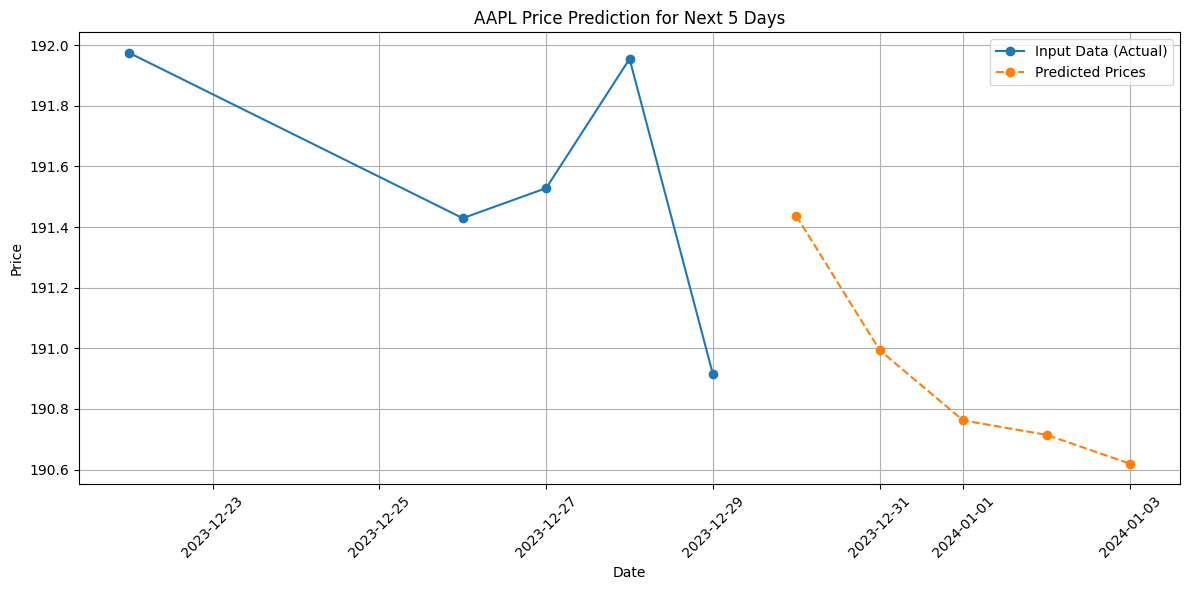

In [7]:
import matplotlib.pyplot as plt

# Predict the next 5 days' prices
n_predict_days = 5
last_sequence = X[-1].reshape(1, input_window, 1) # Get the last sequence from the training data
predicted_prices = []

for _ in range(n_predict_days):
    next_price = model.predict(last_sequence)
    predicted_prices.append(next_price[0, 0])
    # Update the last_sequence by removing the first element and adding the predicted price
    last_sequence = np.append(last_sequence[:, 1:, :], next_price.reshape(1, 1, 1), axis=1)

print("Predicted prices for the next", n_predict_days, "days:", predicted_prices)

# Prepare data for plotting
# Combine actual prices (last part of training data) and predicted prices
# Reshape predicted_prices to have the same number of dimensions as y[-input_window:]
predicted_prices_reshaped = np.array(predicted_prices).reshape(-1, 1)
actual_and_predicted = np.concatenate((y[-input_window:], predicted_prices_reshaped))

dates_for_plot = pd.to_datetime(df['Date'].values[-input_window:]) # Get corresponding dates for the last part of training data
# Generate dates for the predicted days
last_date = dates_for_plot[-1]
predicted_dates = [last_date + pd.Timedelta(days=i) for i in range(1, n_predict_days + 1)]
all_dates = dates_for_plot.tolist() + predicted_dates

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(all_dates[:input_window], y[-input_window:], label='Input Data (Actual)', marker='o')
plt.plot(all_dates[input_window:], predicted_prices, label='Predicted Prices', marker='o', linestyle='--')
# If you have the actual prices for the predicted days, you can add them here for comparison
# plt.plot(actual_dates_for_predicted_days, actual_prices_for_predicted_days, label='Actual Prices (Future)', marker='o')
plt.title(f'{ticker} Price Prediction for Next {n_predict_days} Days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Option 2: Text Data

Locate and identify a basic text classification dataset.  Explore the preprocessing tools from `keras` -- likely the `Tokenizer` and `pad_sequences` functions will be helpful here. ([docs](https://keras.io/api/preprocessing/text/))  Prepare you text data as sequences to present to the network, and use a sequential architecture for the hidden layers.  Build a classification model and compare the performance using a sequential hidden layer architecure compared to a conventional `Dense` layer architecture.

**Note**: The sequential architecture is meant to refer to the hidden layers rather than the `Sequential` model object in `keras`.

Potential Sequential Hidden Layers:

- `SimpleRNN`
- `LSTM`
- `GRU`
- `Conv1D`